# Análisis por subgrupos: equidad del modelo

Un AUC global razonable puede estar escondiendo un modelo que funciona muy bien para unos grupos de pacientes y mal para otros. Antes de dar por bueno el modelo, hay que mirar si lo que aprende generaliza de forma equitativa o si está dejando colgados a determinados perfiles.

Aquí evalúo el rendimiento del LightGBM calibrado dividiendo el test set en cuatro dimensiones:

- **edad**: <45, 45-65, 65-80, >80 años
- **sexo**: femenino / masculino
- **seguro médico**: Medicare, Medicaid u otros
- **diagnóstico principal**: agrupado por sistema orgánico (a partir de la primera posición del código ICD)

Para cada subgrupo se calculan dos cosas: ROC-AUC (cómo discrimina dentro del grupo) y Brier Score comparado con el baseline de predecir siempre la prevalencia del grupo (si la calibración se mantiene). En la sección 4 se añaden además dos métricas de equidad más formales (igualdad de oportunidad y paridad de calibración).

## 1. Imports y carga

In [20]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.models.train import load_data, split_data
from src.data.load import load_csv
from src.config import DATA_INTERIM, FILES
from src.evaluation.evaluate import metrics_by_subgroup, plot_subgroup_auc, plot_subgroup_brier

In [21]:
import numpy as np

# _CalibratedWrapper debe definirse antes de deserializar el modelo calibrado
class _CalibratedWrapper:
    def __init__(self, base_model, ir):
        self.base_model = base_model
        self.ir = ir
    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        cal = self.ir.predict(raw)
        return np.column_stack([1 - cal, cal])

model_path = "../models/lightgbm_calibrated.pkl"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"No se encontró el modelo en {model_path}. Ejecuta primero 04_evaluation.ipynb")
best_model = joblib.load(model_path)
best_model_name = "LightGBM optimizado (calibrado)"

X, y, groups = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Modelo: {best_model_name}")
print(f"Test set: {X_test.shape[0]:,} registros")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Modelo: LightGBM optimizado (calibrado)
Test set: 64,126 registros


## 2. Preparación de subgrupos

El dataset de modelado tiene las categóricas en one-hot, así que hay que recuperar los valores originales desde el dataset intermedio (`cleaned_dataset.csv`), aplicando los mismos filtros del pipeline para que las filas estén bien alineadas.

In [22]:
df = load_csv(DATA_INTERIM / "cleaned_dataset.csv")
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")
df["dischtime"]  = pd.to_datetime(df["dischtime"],  errors="coerce")

# mismos filtros que en run_preprocessing_part2
df = df[df["hospital_expire_flag"] == 0].copy()
df = df.sort_values(["subject_id", "admittime"])
df["next_admittime"] = df.groupby("subject_id")["admittime"].shift(-1)
df = df[df["next_admittime"].notna()].reset_index(drop=True)

# edad real en el momento del ingreso
df["age_at_admission"] = df["anchor_age"] + (
    df["admittime"].dt.year - df["anchor_year"]
)

assert len(df) == len(X), (
    f"Desajuste de filas: interim={len(df)}, model_dataset={len(X)}. "
    "Verifica que los datasets fueron generados desde el mismo pipeline."
)

# verificación de alineamiento por subject_id
if "subject_id" in df.columns:
    groups_test_from_df    = df.loc[X_test.index, "subject_id"].values
    groups_test_from_split = groups.iloc[X_test.index].values
    assert np.array_equal(groups_test_from_df, groups_test_from_split), (
        "Los subject_id no coinciden entre el dataset intermedio y el dataset de modelado. "
        "El orden de filas difiere — verifica el pipeline de preprocesamiento."
    )

print(f"Dataset intermedio cargado: {len(df):,} registros — alineamiento correcto (conteo + subject_id)")

Dataset intermedio cargado: 315,982 registros — alineamiento correcto (conteo + subject_id)


In [23]:
# Grupos de edad
df["age_group"] = pd.cut(
    df["age_at_admission"],
    bins=[0, 45, 65, 80, 200],
    labels=["<45 años", "45–65 años", "65–80 años", ">80 años"]
)

# Sexo
df["gender_label"] = df["gender"].map({"F": "Femenino", "M": "Masculino"})

# Seguro médico
def map_insurance(val):
    if pd.isna(val):
        return "Desconocido"
    v = str(val).strip()
    if v in ("Medicare", "Medicaid"):
        return v
    return "Otro"

df["insurance_group"] = df["insurance"].apply(map_insurance)

print("Distribución de seguros:")
print(df["insurance_group"].value_counts())

Distribución de seguros:
insurance_group
Medicare       151436
Otro            96300
Medicaid        65223
Desconocido      3023
Name: count, dtype: int64


In [24]:
# diagnoses_icd.csv.gz es muy grande — leemos en chunks filtrando seq_num==1 al vuelo
chunks = []
for chunk in pd.read_csv(
    FILES["diagnoses"],
    usecols=["hadm_id", "seq_num", "icd_code", "icd_version"],
    chunksize=500_000,
    low_memory=False
):
    chunks.append(chunk[chunk["seq_num"] == 1])

primary_dx = (
    pd.concat(chunks, ignore_index=True)
    .drop_duplicates(subset="hadm_id")
    [["hadm_id", "icd_code", "icd_version"]]
)
del chunks  

def map_icd_to_system(icd_code, icd_version):
    code = str(icd_code).strip().upper()
    if icd_version == 10:
        letter = code[0] if code else "?"
        mapping = {
            "A": "Infecciosas",   "B": "Infecciosas",
            "C": "Neoplasias",    "D": "Neoplasias",
            "E": "Endocrinas/Metabólicas",
            "F": "Salud mental",
            "G": "Sistema nervioso",
            "H": "Ojo/Oído",
            "I": "Sist. circulatorio",
            "J": "Sist. respiratorio",
            "K": "Sist. digestivo",
            "L": "Piel",
            "M": "Sist. musculoesquelético",
            "N": "Sist. genitourinario",
            "O": "Embarazo/Parto",
            "R": "Síntomas inespecíficos",
            "S": "Traumatismos",  "T": "Traumatismos",
        }
        return mapping.get(letter, "Otros")
    else:  # ICD-9
        try:
            num = int(code[:3])
            if num < 140: return "Infecciosas"
            if num < 240: return "Neoplasias"
            if num < 280: return "Endocrinas/Metabólicas"
            if num < 320: return "Salud mental"
            if num < 390: return "Sistema nervioso"
            if num < 460: return "Sist. circulatorio"
            if num < 520: return "Sist. respiratorio"
            if num < 580: return "Sist. digestivo"
            if num < 630: return "Sist. genitourinario"
            if num < 800: return "Otros"
            return "Traumatismos"
        except ValueError:
            return "Otros"

primary_dx = primary_dx.copy()
primary_dx["diag_system"] = primary_dx.apply(
    lambda r: map_icd_to_system(r["icd_code"], r["icd_version"]), axis=1
)

df = df.merge(primary_dx[["hadm_id", "diag_system"]], on="hadm_id", how="left")
df["diag_system"] = df["diag_system"].fillna("No especificado")

print("Distribución de sistemas diagnósticos:")
print(df["diag_system"].value_counts())

Distribución de sistemas diagnósticos:
diag_system
Otros                       54117
Sist. circulatorio          51629
Sist. digestivo             37543
Traumatismos                31782
Salud mental                28421
Neoplasias                  21886
Sist. respiratorio          17045
Sist. genitourinario        14717
Endocrinas/Metabólicas      13959
Infecciosas                 12668
Sistema nervioso             9309
Síntomas inespecíficos       9268
Sist. musculoesquelético     6161
Embarazo/Parto               4557
Piel                         2234
Ojo/Oído                      373
No especificado               313
Name: count, dtype: int64


## 3. Análisis por subgrupos

Para cada subgrupo calculo sobre el test set:
- **ROC-AUC**: qué tan bien discrimina el modelo en ese grupo
- **Brier Score**: si las probabilidades predichas son razonables, comparado con predecir siempre la prevalencia del grupo

### 3.1 Grupos de edad

  Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
  <45 años 14080        0.369    0.690        0.208           0.233
45–65 años 23410        0.362    0.656        0.213           0.231
65–80 años 17335        0.327    0.639        0.208           0.220
  >80 años  9301        0.303    0.613        0.205           0.211


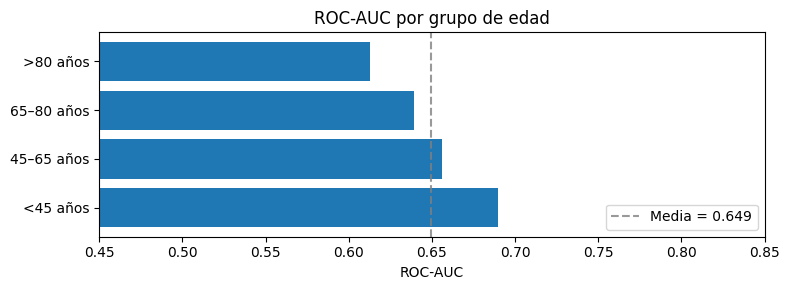

<Axes: title={'center': 'ROC-AUC por grupo de edad'}, xlabel='ROC-AUC'>

In [25]:
age_test = df["age_group"].loc[X_test.index]
age_df = metrics_by_subgroup(best_model, X_test, y_test, age_test)
print(age_df.to_string(index=False))
plot_subgroup_auc(age_df, "grupo de edad",
                  save_path="../results/subgroup_age.png")

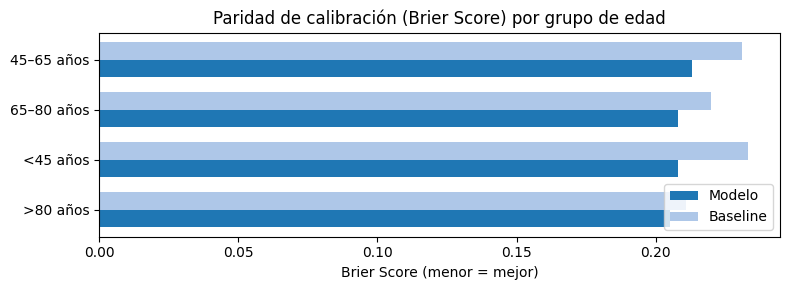

<Axes: title={'center': 'Paridad de calibración (Brier Score) por grupo de edad'}, xlabel='Brier Score (menor = mejor)'>

In [26]:
plot_subgroup_brier(age_df, "grupo de edad",
                    save_path="../results/subgroup_brier_age.png")

### 3.2 Sexo

 Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
Masculino 30995        0.370    0.656        0.215           0.233
 Femenino 33131        0.323    0.654        0.204           0.219


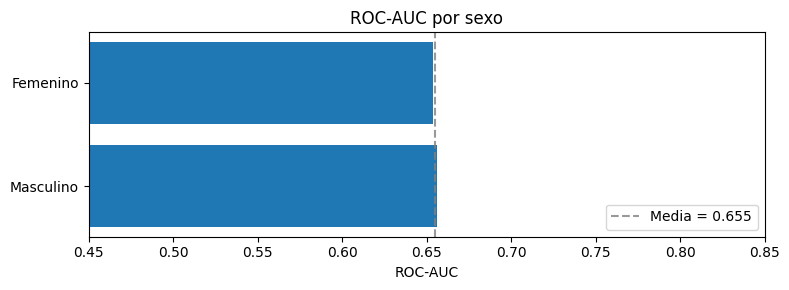

<Axes: title={'center': 'ROC-AUC por sexo'}, xlabel='ROC-AUC'>

In [27]:
gender_test = df["gender_label"].loc[X_test.index]
gender_df = metrics_by_subgroup(best_model, X_test, y_test, gender_test)
print(gender_df.to_string(index=False))
plot_subgroup_auc(gender_df, "sexo",
                  save_path="../results/subgroup_gender.png")

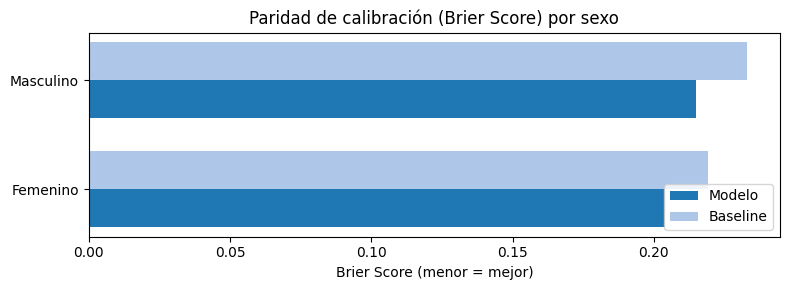

<Axes: title={'center': 'Paridad de calibración (Brier Score) por sexo'}, xlabel='Brier Score (menor = mejor)'>

In [28]:
plot_subgroup_brier(gender_df, "sexo",
                    save_path="../results/subgroup_brier_gender.png")

### 3.3 Tipo de seguro médico

   Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
Desconocido   579        0.491    0.693        0.221           0.250
       Otro 19150        0.330    0.674        0.202           0.221
   Medicaid 14151        0.386    0.669        0.216           0.237
   Medicare 30246        0.334    0.633        0.211           0.222


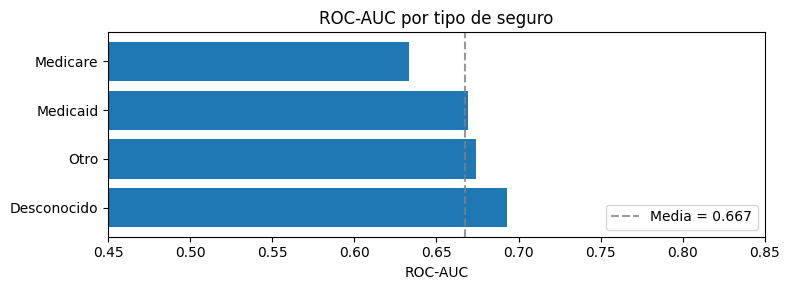

<Axes: title={'center': 'ROC-AUC por tipo de seguro'}, xlabel='ROC-AUC'>

In [29]:
insurance_test = df["insurance_group"].loc[X_test.index]
insurance_df = metrics_by_subgroup(best_model, X_test, y_test, insurance_test)
print(insurance_df.to_string(index=False))
plot_subgroup_auc(insurance_df, "tipo de seguro",
                  save_path="../results/subgroup_insurance.png")

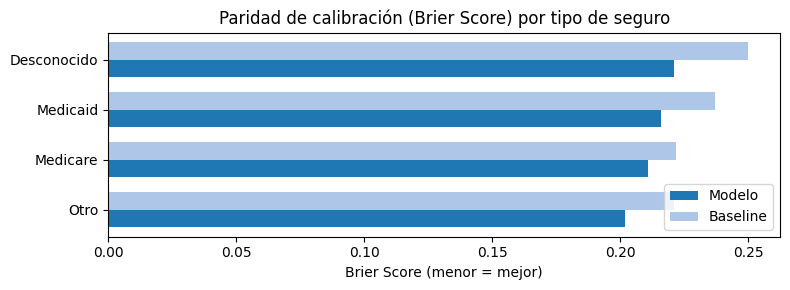

<Axes: title={'center': 'Paridad de calibración (Brier Score) por tipo de seguro'}, xlabel='Brier Score (menor = mejor)'>

In [30]:
plot_subgroup_brier(insurance_df, "tipo de seguro",
                    save_path="../results/subgroup_brier_insurance.png")

### 3.4 Diagnóstico principal

                Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
         No especificado    56        0.393    0.769        0.187           0.239
                   Otros 10665        0.300    0.731        0.181           0.210
          Embarazo/Parto   906        0.247    0.699        0.170           0.186
            Salud mental  6114        0.529    0.652        0.238           0.249
              Neoplasias  4514        0.392    0.652        0.226           0.238
      Sist. respiratorio  3598        0.305    0.646        0.199           0.212
  Endocrinas/Metabólicas  2743        0.330    0.629        0.212           0.221
            Traumatismos  6425        0.344    0.629        0.215           0.226
  Síntomas inespecíficos  1968        0.303    0.623        0.205           0.211
             Infecciosas  2633        0.370    0.620        0.223           0.233
    Sist. genitourinario  2973        0.308    0.619        0.206           0.213
        Sistema 

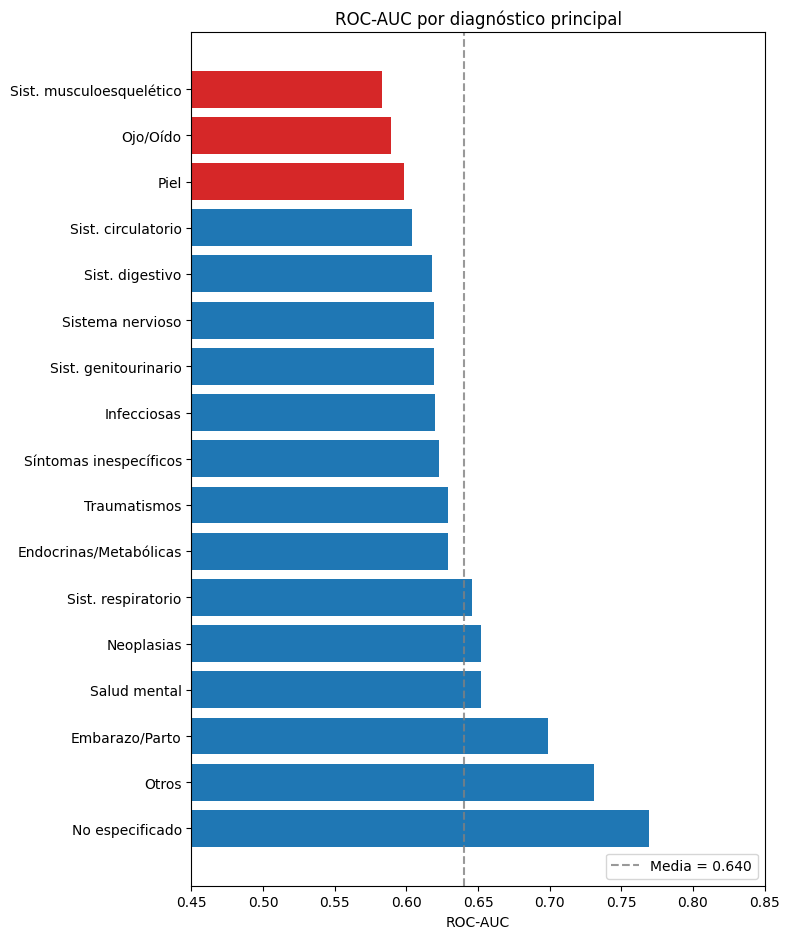

<Axes: title={'center': 'ROC-AUC por diagnóstico principal'}, xlabel='ROC-AUC'>

In [31]:
diag_test = df["diag_system"].loc[X_test.index]
diag_df = metrics_by_subgroup(best_model, X_test, y_test, diag_test)
print(diag_df.to_string(index=False))
plot_subgroup_auc(diag_df, "diagnóstico principal",
                  save_path="../results/subgroup_diagnosis.png")

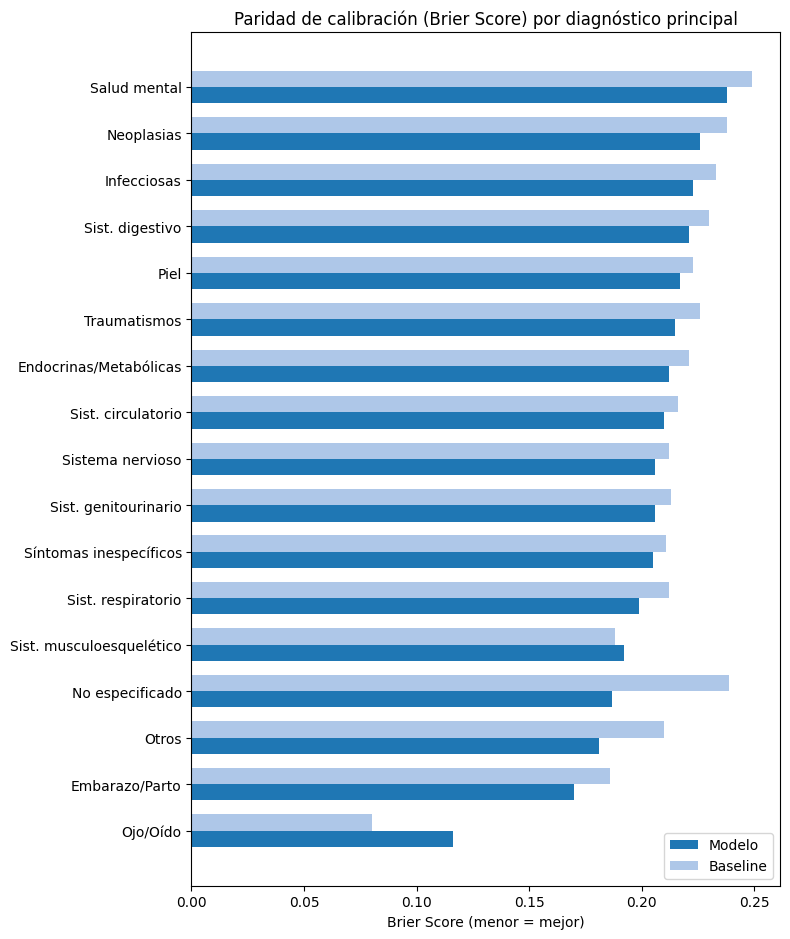

<Axes: title={'center': 'Paridad de calibración (Brier Score) por diagnóstico principal'}, xlabel='Brier Score (menor = mejor)'>

In [32]:
plot_subgroup_brier(diag_df, "diagnóstico principal",
                    save_path="../results/subgroup_brier_diagnosis.png")

## 4. Métricas de equidad formal

Lo de la sección anterior ya da una buena foto descriptiva, pero merece la pena pasarlo a través de un par de criterios más formales que se usan en la literatura de fairness en ML. Sigo el planteamiento del libro de Barocas, Hardt y Narayanan (2019), que es bastante el estándar para esto:

- **Igualdad de oportunidad** (*equal opportunity*): el TPR (la sensibilidad, los reingresos que el modelo detecta) debería ser parecido en todos los grupos al mismo umbral. Si en un grupo el modelo detecta el 80 % de reingresos y en otro el 45 %, aunque el AUC global salga bien, en la práctica está fallando mucho más a los del segundo grupo.
- **Paridad de calibración** (*calibration parity*): el ECE debería ser similar entre subgrupos. Si el modelo está bien calibrado en general pero descalibrado en un grupo concreto, ese grupo no se beneficia de las probabilidades (son menos fiables).

> El Brier Score por subgrupo de la sección 3 ya apunta a esto, pero el ECE separado por grupo es más directo y se compara mejor con el ECE global de 0,007 que salió en `04_evaluation.ipynb` para el modelo calibrado.

### 4.1 Funciones auxiliares

In [33]:
from sklearn.metrics import confusion_matrix

# Umbral usado en el análisis de umbral de 04_evaluation.ipynb
# El umbral óptimo del modelo SIN calibrar es 0.40 (ver 04_evaluation.ipynb).
# Para el modelo calibrado se usa 0.35: la calibración isotónica cambia la escala
# de las probabilidades, por lo que el umbral operativo es diferente.
THRESHOLD = 0.35


def equal_opportunity_by_subgroup(model, X, y, groups, threshold=THRESHOLD, min_samples=50):
    """TPR (sensibilidad) y FPR por subgrupo al umbral dado — equal opportunity."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    y_arr  = np.asarray(y)
    g_arr  = np.asarray(groups)
    rows = []
    for g in sorted(set(g_arr), key=str):
        mask = g_arr == g
        if mask.sum() < min_samples or len(np.unique(y_arr[mask])) < 2:
            continue
        tn, fp, fn, tp = confusion_matrix(y_arr[mask], y_pred[mask]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
        rows.append({"Subgrupo": str(g), "N": int(mask.sum()),
                     "TPR (Sensibilidad)": round(tpr, 3),
                     "FPR (1-Especificidad)": round(fpr, 3)})
    return pd.DataFrame(rows)


def ece_by_subgroup(model, X, y, groups, n_bins=10, min_samples=50):
    """ECE (Expected Calibration Error) por subgrupo — calibration parity."""
    y_prob = model.predict_proba(X)[:, 1]
    y_arr  = np.asarray(y)
    g_arr  = np.asarray(groups)
    rows = []
    for g in sorted(set(g_arr), key=str):
        mask = g_arr == g
        if mask.sum() < min_samples:
            continue
        yp, ya = y_prob[mask], y_arr[mask]
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_ids   = np.digitize(yp, bin_edges[1:-1])
        ece = 0.0
        for b in range(n_bins):
            m = bin_ids == b
            if m.sum() == 0:
                continue
            ece += (m.sum() / len(yp)) * abs(ya[m].mean() - yp[m].mean())
        rows.append({"Subgrupo": str(g), "N": int(mask.sum()), "ECE": round(ece, 4)})
    return pd.DataFrame(rows).sort_values("ECE", ascending=True).reset_index(drop=True)


### 4.2 Igualdad de oportunidad (Equal Opportunity)

Sensibilidad (TPR) por subgrupo al umbral `THRESHOLD = 0.35`. Si entre los grupos hay diferencias grandes, el modelo está detectando reingresos reales de forma desigual.

> Nota: el umbral 0,35 se usa aquí porque el modelo que carga este notebook es el calibrado isotónicamente. El umbral 0,40 que se vio en `04_evaluation.ipynb` corresponde al modelo sin calibrar (al recalibrar cambia la escala de probabilidades y, con ella, el umbral operativo equivalente).

In [34]:
eo_age       = equal_opportunity_by_subgroup(best_model, X_test, y_test, df["age_group"].loc[X_test.index])
eo_gender    = equal_opportunity_by_subgroup(best_model, X_test, y_test, df["gender_label"].loc[X_test.index])
eo_insurance = equal_opportunity_by_subgroup(best_model, X_test, y_test, df["insurance_group"].loc[X_test.index])
eo_diag      = equal_opportunity_by_subgroup(best_model, X_test, y_test, df["diag_system"].loc[X_test.index])

print("--- Equal Opportunity por grupo de edad ---")
print(eo_age.to_string(index=False))
print("\n--- Equal Opportunity por sexo ---")
print(eo_gender.to_string(index=False))
print("\n--- Equal Opportunity por seguro médico ---")
print(eo_insurance.to_string(index=False))
print("\n--- Equal Opportunity por diagnóstico ---")
print(eo_diag.to_string(index=False))


--- Equal Opportunity por grupo de edad ---
  Subgrupo     N  TPR (Sensibilidad)  FPR (1-Especificidad)
45–65 años 23410               0.653                  0.442
65–80 años 17335               0.570                  0.373
  <45 años 14080               0.759                  0.501
  >80 años  9301               0.447                  0.292

--- Equal Opportunity por sexo ---
 Subgrupo     N  TPR (Sensibilidad)  FPR (1-Especificidad)
 Femenino 33131               0.562                  0.348
Masculino 30995               0.695                  0.486

--- Equal Opportunity por seguro médico ---
   Subgrupo     N  TPR (Sensibilidad)  FPR (1-Especificidad)
Desconocido   579               0.845                  0.705
   Medicaid 14151               0.728                  0.511
   Medicare 30246               0.578                  0.389
       Otro 19150               0.621                  0.374

--- Equal Opportunity por diagnóstico ---
                Subgrupo     N  TPR (Sensibilidad)

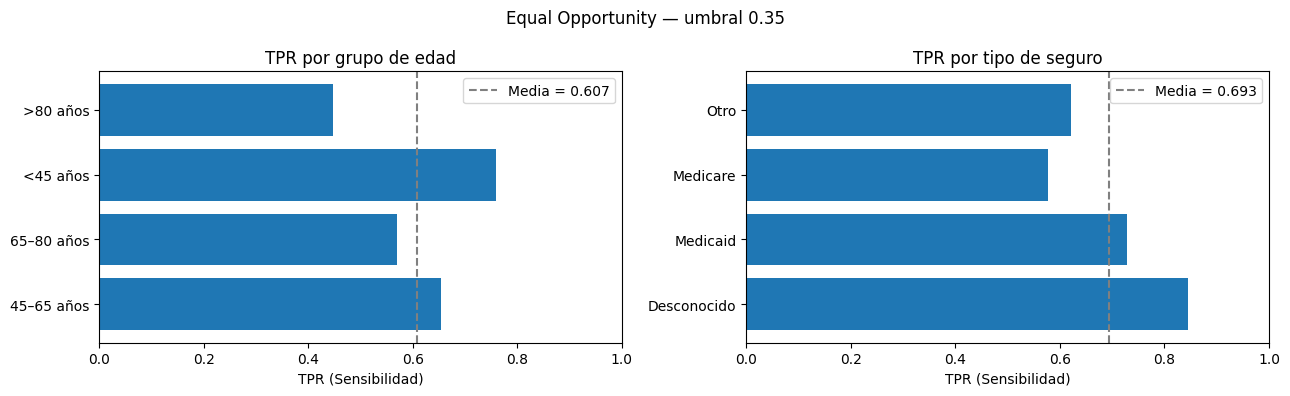

In [35]:
# Visualización: TPR por grupo de edad y por seguro (dimensiones con más variación esperada)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df_eo, title in [
    (axes[0], eo_age,       "TPR por grupo de edad"),
    (axes[1], eo_insurance, "TPR por tipo de seguro"),
]:
    ax.barh(df_eo["Subgrupo"], df_eo["TPR (Sensibilidad)"], color="#1f77b4")
    media = df_eo["TPR (Sensibilidad)"].mean()
    ax.axvline(media, color="gray", linestyle="--", label=f"Media = {media:.3f}")
    ax.set_xlabel("TPR (Sensibilidad)")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.legend()

plt.suptitle(f"Equal Opportunity — umbral {THRESHOLD}", fontsize=12)
plt.tight_layout()
plt.savefig("../results/equal_opportunity.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3 Paridad de calibración (ECE por subgrupo)

El ECE mide cuánto se desvían las probabilidades predichas de la frecuencia real de reingresos. Si el ECE varía mucho entre grupos, el modelo no es igualmente fiable para todos. El ECE global del modelo calibrado fue 0.007 (ver `04_evaluation.ipynb`).

In [36]:
ece_age       = ece_by_subgroup(best_model, X_test, y_test, df["age_group"].loc[X_test.index])
ece_gender    = ece_by_subgroup(best_model, X_test, y_test, df["gender_label"].loc[X_test.index])
ece_insurance = ece_by_subgroup(best_model, X_test, y_test, df["insurance_group"].loc[X_test.index])
ece_diag      = ece_by_subgroup(best_model, X_test, y_test, df["diag_system"].loc[X_test.index])

print("--- ECE por grupo de edad ---")
print(ece_age.to_string(index=False))
print("\n--- ECE por sexo ---")
print(ece_gender.to_string(index=False))
print("\n--- ECE por seguro médico ---")
print(ece_insurance.to_string(index=False))
print("\n--- ECE por diagnóstico ---")
print(ece_diag.to_string(index=False))


--- ECE por grupo de edad ---
  Subgrupo     N    ECE
65–80 años 17335 0.0078
  <45 años 14080 0.0079
45–65 años 23410 0.0094
  >80 años  9301 0.0128

--- ECE por sexo ---
 Subgrupo     N    ECE
Masculino 30995 0.0047
 Femenino 33131 0.0108

--- ECE por seguro médico ---
   Subgrupo     N    ECE
       Otro 19150 0.0078
   Medicare 30246 0.0084
   Medicaid 14151 0.0102
Desconocido   579 0.0550

--- ECE por diagnóstico ---
                Subgrupo     N    ECE
    Sist. genitourinario  2973 0.0202
            Traumatismos  6425 0.0210
             Infecciosas  2633 0.0216
      Sist. circulatorio 10554 0.0217
  Endocrinas/Metabólicas  2743 0.0232
         Sist. digestivo  7372 0.0244
                   Otros 10665 0.0267
        Sistema nervioso  1851 0.0358
          Embarazo/Parto   906 0.0398
  Síntomas inespecíficos  1968 0.0419
      Sist. respiratorio  3598 0.0444
                    Piel   478 0.0475
              Neoplasias  4514 0.0626
Sist. musculoesquelético  1208 0.0635
    

### 4.4 Tabla resumen de equidad formal

In [37]:
def add_dim(df, label):
    df = df.copy(); df.insert(0, 'Dimensión', label); return df

summary_eo = pd.concat([
    add_dim(eo_age,       "Edad"),
    add_dim(eo_gender,    "Sexo"),
    add_dim(eo_insurance, "Seguro"),
    add_dim(eo_diag,      "Diagnóstico"),
], ignore_index=True)

summary_ece = pd.concat([
    add_dim(ece_age,       "Edad"),
    add_dim(ece_gender,    "Sexo"),
    add_dim(ece_insurance, "Seguro"),
    add_dim(ece_diag,      "Diagnóstico"),
], ignore_index=True)

print("=== EQUAL OPPORTUNITY (TPR por subgrupo al umbral", THRESHOLD, ") ===")
display(summary_eo)

print("\n=== CALIBRATION PARITY (ECE por subgrupo) ===")
display(summary_ece)


=== EQUAL OPPORTUNITY (TPR por subgrupo al umbral 0.35 ) ===


,Dimensión,Subgrupo,N,TPR (Sensibilidad),FPR (1-Especificidad)
0,Edad,45–65 años,23410,0.653,0.442
1,Edad,65–80 años,17335,0.570,0.373
2,Edad,<45 años,14080,0.759,0.501
3,Edad,>80 años,9301,0.447,0.292
4,Sexo,Femenino,33131,0.562,0.348
5,Sexo,Masculino,30995,0.695,0.486
6,Seguro,Desconocido,579,0.845,0.705
7,Seguro,Medicaid,14151,0.728,0.511
8,Seguro,Medicare,30246,0.578,0.389
9,Seguro,Otro,19150,0.621,0.374



=== CALIBRATION PARITY (ECE por subgrupo) ===


,Dimensión,Subgrupo,N,ECE
0,Edad,65–80 años,17335,0.0078
1,Edad,<45 años,14080,0.0079
2,Edad,45–65 años,23410,0.0094
3,Edad,>80 años,9301,0.0128
4,Sexo,Masculino,30995,0.0047
5,Sexo,Femenino,33131,0.0108
6,Seguro,Otro,19150,0.0078
7,Seguro,Medicare,30246,0.0084
8,Seguro,Medicaid,14151,0.0102
9,Seguro,Desconocido,579,0.0550


## 5. Visión global

Tabla comparativa de todas las métricas por subgrupo y dimensión, para tener todos los resultados a la vista en un único sitio.

In [38]:
def add_dimension(df, label):
    df = df.copy()
    df.insert(0, "Dimensión", label)
    return df

summary = pd.concat([
    add_dimension(age_df,       "Edad"),
    add_dimension(gender_df,    "Sexo"),
    add_dimension(insurance_df, "Seguro"),
    add_dimension(diag_df,      "Diagnóstico"),
], ignore_index=True)

summary

,Dimensión,Subgrupo,N,Prevalencia,ROC-AUC,Brier-Score,Brier-Baseline
0,Edad,<45 años,14080,0.369,0.690,0.208,0.233
1,Edad,45–65 años,23410,0.362,0.656,0.213,0.231
2,Edad,65–80 años,17335,0.327,0.639,0.208,0.220
3,Edad,>80 años,9301,0.303,0.613,0.205,0.211
4,Sexo,Masculino,30995,0.370,0.656,0.215,0.233
5,Sexo,Femenino,33131,0.323,0.654,0.204,0.219
6,Seguro,Desconocido,579,0.491,0.693,0.221,0.250
7,Seguro,Otro,19150,0.330,0.674,0.202,0.221
8,Seguro,Medicaid,14151,0.386,0.669,0.216,0.237
9,Seguro,Medicare,30246,0.334,0.633,0.211,0.222


## 6. Conclusiones

En conjunto el modelo se comporta razonablemente equitativo, aunque hay tres o cuatro cosas que merece la pena destacar.

**En discriminación (ROC-AUC):**

- En **edad** hay un gradiente claro y bastante esperable: el modelo va mejor en pacientes jóvenes (AUC 0,690 en menores de 45) que en mayores de 80 (AUC 0,613). Probablemente porque a más edad hay más comorbilidades y más heterogeneidad, y las pocas variables administrativas que se manejan aquí no capturan bien esa complejidad.
- En **sexo** apenas hay diferencia (0,656 vs 0,654). Buena señal (el modelo no parece estar favoreciendo sistemáticamente a un grupo sobre otro en términos de discriminación).
- En **tipo de seguro**, Medicare es el que peor sale (AUC 0,633). El seguro funciona como un proxy socioeconómico, así que esto probablemente refleja diferencias en los patrones de reingreso entre poblaciones, no un defecto del modelo en sí.
- En **diagnóstico principal** es donde más variación se ve, lo cual también es esperable: desde AUC 0,731 en "Otros" hasta 0,583 en musculoesquelético. Los grupos con patologías más específicas tienden a tener factores de reingreso que las variables administrativas no recogen bien.

**En calibración (Brier Score y ECE):**

La calibración es algo más irregular. La mayoría de grupos mejora respecto al baseline de prevalencia del grupo, pero hay subgrupos pequeños (Salud mental, Neoplasias, Musculoesquelético) donde el ECE se dispara por encima de 0,06. El modelo que se carga aquí es ya el calibrado isotónicamente (`lightgbm_calibrated.pkl`); aun así, la calibración global no garantiza calibración por subgrupo.

**En equal opportunity:**

La sensibilidad varía bastante entre grupos al mismo umbral, especialmente por edad (de 0,759 en <45 años a 0,447 en >80) y por sexo (0,562 femenino vs 0,695 masculino). Esto significa que con un umbral fijo el modelo está siendo más permisivo para detectar reingresos en unos grupos que en otros. Si el modelo se usara en producción, habría que plantearse umbrales por subgrupo o asumir explícitamente esta diferencia.

**Resumen:** AUC por encima de 0,60 en casi todos los subgrupos es razonable para variables exclusivamente administrativas, pero la equidad no es perfecta y conviene tenerlo presente para cualquier despliegue real.

> **Aviso sobre subgrupos pequeños:** los grupos con N < 100 ("No especificado", N=56 y "Ojo/Oído", N=68) aparecen en las tablas para no esconder nada, pero **no deben interpretarse** (con esa muestra los IC son tan amplios que cualquier número que salga no es informativo).